In [10]:
# Homework 6 Template
# G. Besla & R. Li 

In [11]:
# import modules
import numpy as np # import numpy
import astropy.units as u # import astropy units
from astropy import constants as const # import astropy constants 
from astropy.constants import G # import the gravity constant
# import plotting modules
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
# my modules
from ReadFile import Read
# Step 1: modify CenterOfMass so that COM_P now takes a parameter specifying 
# by how much to decrease RMAX instead of a factor of 2
from CenterOfMass2 import CenterOfMass



In [12]:
def OrbitCOM(galaxy, start, end, n):
    """function that loops over all the desired snapshots to compute the COM pos and vel as a function of time.
    inputs: galaxy: the name of the galaxy (MW,M31,M33)
    start: number of the first snapshot to be read
    end: number of the last snapshot to be read (800)
    n: int, the intervals to return the COM (n=5)
    outputs: filename: the data for the orbital evolution of each galaxy will be store to a file
    """
    # compose the filename for output
    fileout = "Orbit_" + galaxy + ".txt" # define a string for the filename to be saved as 
    #  set tolerance and VolDec for calculating COM_P in CenterOfMass
    # for M33 that is stripped more, use different values for VolDec
    delta = 0.1 # value when it will starts to stop
    volDec = 2 # value for the volume decrement which the radius will shrink
    # since the galaxy will be tidally stripped we need to adjust its value
    if galaxy == "M33":
        volDec = 4
    # generate the snapshot id sequence 
    # it is always a good idea to also check if the input is eligible (not required)
    snap_ids = np.array(np.arange(start, end, n)) # storing the snapshot's id sequence
    # checking if the array is empty
    if len(snap_ids) == 0:
        print("Input Not Eligible")
        return
    # initialize the array for orbital info: t, x, y, z, vx, vy, vz of COM
    orbit = np.zeros([len(snap_ids),7]) #array that stores all information of the COM of the galaxies at each snapshot
    
    # a for loop 
    #loops over the files to compute the COM position and velocities at each snapshot
    for i, snap_id in enumerate(snap_ids): 
        # compose the data filename (be careful about the folder)
        ilbl = '000' + str(snap_id)
        #remove all but the last 3 digits
        ilbl = ilbl[-3:]
        filename = (f"./{galaxy}/{galaxy}_{ilbl}.txt" ) # this will make it easier to input
        # Initialize an instance of CenterOfMass class, using disk particles
        COM = CenterOfMass(filename,2) # COM object with disk particles only
        # Store the COM pos and vel. Remember that now COM_P required VolDec
        COM_p = COM.COM_P(delta, volDec) # storing the position of COM
        COM_v = COM.COM_V(COM_p[0],COM_p[1], COM_p[2]) # storing the velocity of COM
    
        # store the time, pos, vel in ith element of the orbit array,  without units (.value) 
        # note that you can store 
        # a[i] = var1, *tuple(array1)
        time = COM.time/1000 # the first column of orbit is the time in GYR
        orbit[i][0] = time.value # this is the time stored
        orbit[i][1] = COM_p[0].value # this is the pos x stored
        orbit[i][2] = COM_p[1].value # this is the pos y stored
        orbit[i][3] = COM_p[2].value # this is the pos z stored
        orbit[i][4] = COM_v[0].value # this is the vel vx stored
        orbit[i][5] = COM_v[1].value # this is the vel vy stored
        orbit[i][6] = COM_v[2].value # this is the vel vz stored
        # print snap_id to see the progress
        print("Counter:", snap_id) # counter of the for loop so we can track
        
    # write the data to a file
    # we do this because we don't want to have to repeat this process 
    # this code should only have to be called once per galaxy.
    np.savetxt(fileout, orbit, fmt = "%11.3f"*7, comments='#',
               header="{:>10s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}"\
                      .format('t', 'x', 'y', 'z', 'vx', 'vy', 'vz'))

In [29]:
# Recover the orbits and generate the COM files for each galaxy
# read in 800 snapshots in intervals of n=5
# Note: This might take a little while - test your code with a smaller number of snapshots first! 
# MW orbit
#OrbitCOM('MW', 0,800,5)
#M31 orbit
#OrbitCOM('M31', 0,800,5)
# m33 Orbit
# OrbitCOM('M33', 0,30,5)
# I got all the files for each galaxy up to 800 snapshot but it got over crowded so I just did 30 here

CHANGE =  0.0030916524717667926
maxR 4.229774935346835
Counter: 0
CHANGE =  0.000632604552038174
maxR 4.133379335699456
Counter: 5
CHANGE =  0.031303003336233814
maxR 4.097427211993776
Counter: 10
CHANGE =  0.05770428114999504
maxR 4.180980033458458
Counter: 15
CHANGE =  0.052517004245032695
maxR 4.1705511970407905
Counter: 20
CHANGE =  6.673321126982046e-05
maxR 4.07607610279739
Counter: 25


In [13]:
# Read in the data files for the orbits of each galaxy that you just created
# headers:  t, x, y, z, vx, vy, vz
# using np.genfromtxt
# first lets name the files for each galaxy
filename1 = "Orbit_MW.txt"
filename2 = "Orbit_M31.txt"
filename3 = "Orbit_M33.txt"
# then make it read the data files of the orbit of each galaxy
data1 = np.genfromtxt(filename1, comments= '#', names= True)
data2 = np.genfromtxt(filename2, comments= '#', names= True)
data3 = np.genfromtxt(filename3, comments= '#', names= True)
# now we can get the data
#time
time1 = data1['t']
time2 = data2['t']
time3 = data3['t']
# postion
pos1 = (data1['x'],data1['y'],data1['z'])
pos2 = (data2['x'],data2['y'],data2['z'])
pos3 = (data3['x'],data3['y'],data3['z'])
# velocity
vel1 = (data1['vx'],data1['vy'],data1['vz'])
vel2 = (data2['vx'],data2['vy'],data2['vz'])
vel3 = (data3['vx'],data3['vy'],data3['vz'])

In [14]:
# function to compute the magnitude of the difference between two vectors 
# You can use this function to return both the relative position and relative velocity for two 
# galaxies over the entire orbit  
def MagDiff(G1,G2):
    """Function that computes the difference between two vectors which in this is two galaxies. used for both velocity and position
        x1: is the first galaxy which we compute its magnitude of pos/vel
        x2: the second galaxy 
    outputs: Sep: the magnitude of the relative seperation and the velocity
    """
    x1,y1,z1 = G1 # this is the first galaxy which will take the x,y,z positions/velocity
    x2,y2,z2 = G2 # this is the 2nd galaxy which will take the x,y,z positions/velocity
    xnew = x2 - x1 # taking the difference of each galaxies position/velocity before we take the magnitude of it all
    ynew = y2 - y1
    znew = z2 - z1
    sep = np.sqrt((xnew**2) + (ynew**2) + (znew**2)) # now we take the square root of it all
    return sep # this is the magnitude of the difference between two vectors

In [15]:
# Determine the magnitude of the relative position and velocities 
# of MW and M31
# I implemented my data from before to make it easier
RelPosMWM31 = MagDiff(pos1,pos2)
print("Relative Position MW-M31:", RelPosMWM31 ) # tested code to see if it works
VelMWM31 = MagDiff(vel1,vel2)
# of M33 and M31
RelPosM33M31 = MagDiff(pos3,pos2)
VelM33M31 = MagDiff(vel3,vel2)

Relative Position MW-M31: [7.69120299e+02 7.61115872e+02 7.52887097e+02 7.44309862e+02
 7.35605632e+02 7.26920019e+02 7.17789942e+02 7.08555289e+02
 6.99603077e+02 6.90879781e+02 6.82590113e+02 6.74300445e+02
 6.65917757e+02 6.57727242e+02 6.49428408e+02 6.41853750e+02
 6.34022528e+02 6.26010148e+02 6.17788923e+02 6.09389545e+02
 6.00966103e+02 5.92220582e+02 5.83118594e+02 5.73604549e+02
 5.63682100e+02 5.53509158e+02 5.43263729e+02 5.32124769e+02
 5.20678008e+02 5.08763631e+02 4.96417790e+02 4.83728460e+02
 4.70871963e+02 4.57652695e+02 4.44160177e+02 4.30360690e+02
 4.15910429e+02 4.01218284e+02 3.86407789e+02 3.71308461e+02
 3.55537122e+02 3.39421263e+02 3.23254707e+02 3.05421461e+02
 2.87569643e+02 2.69242933e+02 2.50215343e+02 2.30390123e+02
 2.09593109e+02 1.87750452e+02 1.64822152e+02 1.40584183e+02
 1.14884109e+02 8.78579911e+01 6.04559592e+01 3.82741087e+01
 4.00961407e+01 6.19416605e+01 8.57967867e+01 1.06548195e+02
 1.23659073e+02 1.37633521e+02 1.48692607e+02 1.57441179e+0

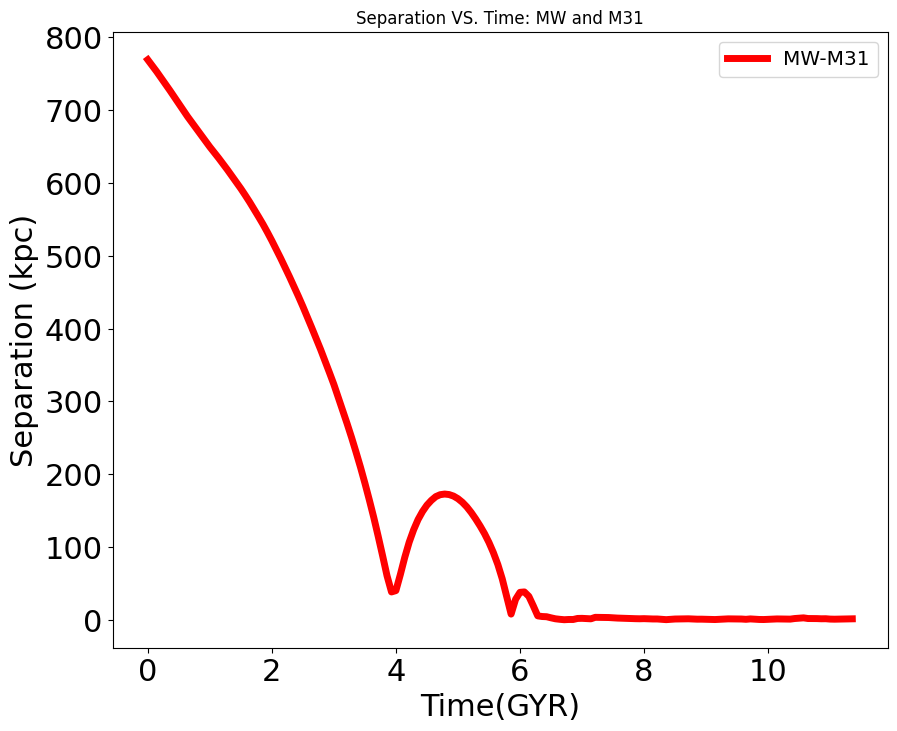

In [16]:
# Plot the Orbit of the galaxies 
#################################
fig,ax = plt.subplots(figsize=(10,8))

#adjust tick label font size
label_size = 22
matplotlib.rcParams['xtick.labelsize'] = label_size 
matplotlib.rcParams['ytick.labelsize'] = label_size
#plot magnitude of separation vs time for MW and M31
plt.plot(time1, RelPosMWM31 ,color = "red", linewidth = 5, label='MW-M31')

# Axes labels 
plt.xlabel('Time(GYR)',fontsize=22) 
plt.ylabel('Separation (kpc)', fontsize=22)
plt.title("Separation VS. Time: MW and M31")
# Legend
plt.legend(loc='upper right',fontsize='x-large')
plt.show()

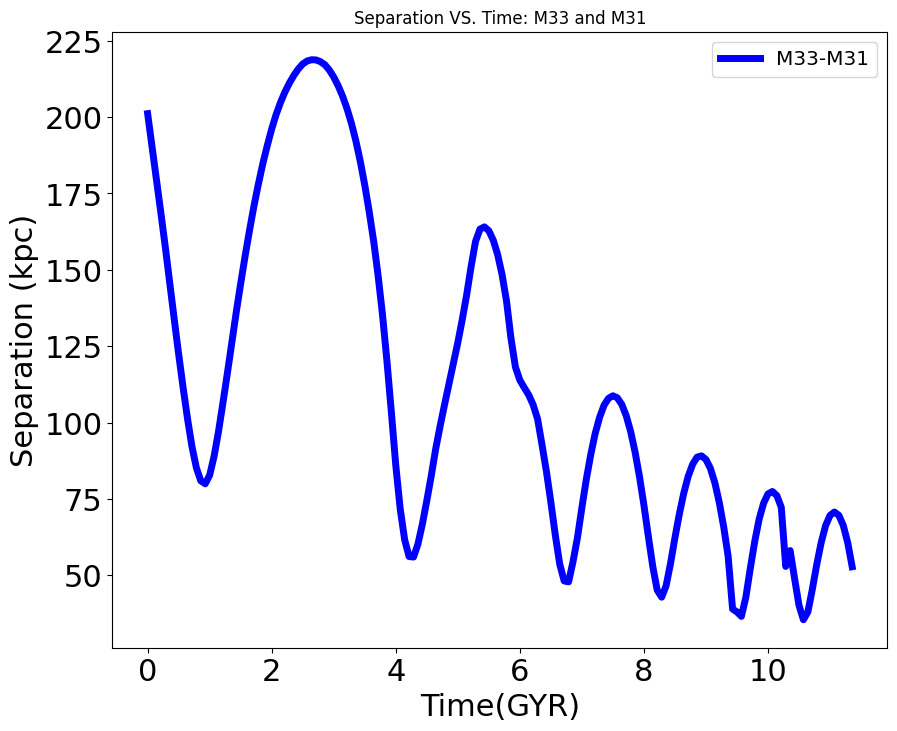

In [17]:
fig,ax = plt.subplots(figsize=(10,8))

#adjust tick label font size
label_size = 22
matplotlib.rcParams['xtick.labelsize'] = label_size 
matplotlib.rcParams['ytick.labelsize'] = label_size
#plot magnitude of separation vs time for M33 and M31
plt.plot(time2, RelPosM33M31 ,color = "blue", linewidth = 5, label='M33-M31')
# Axes labels 
plt.xlabel('Time(GYR)',fontsize=22) 
plt.ylabel('Separation (kpc)', fontsize=22)
plt.title("Separation VS. Time: M33 and M31")
# Legend
plt.legend(loc='upper right',fontsize='x-large')
plt.show()

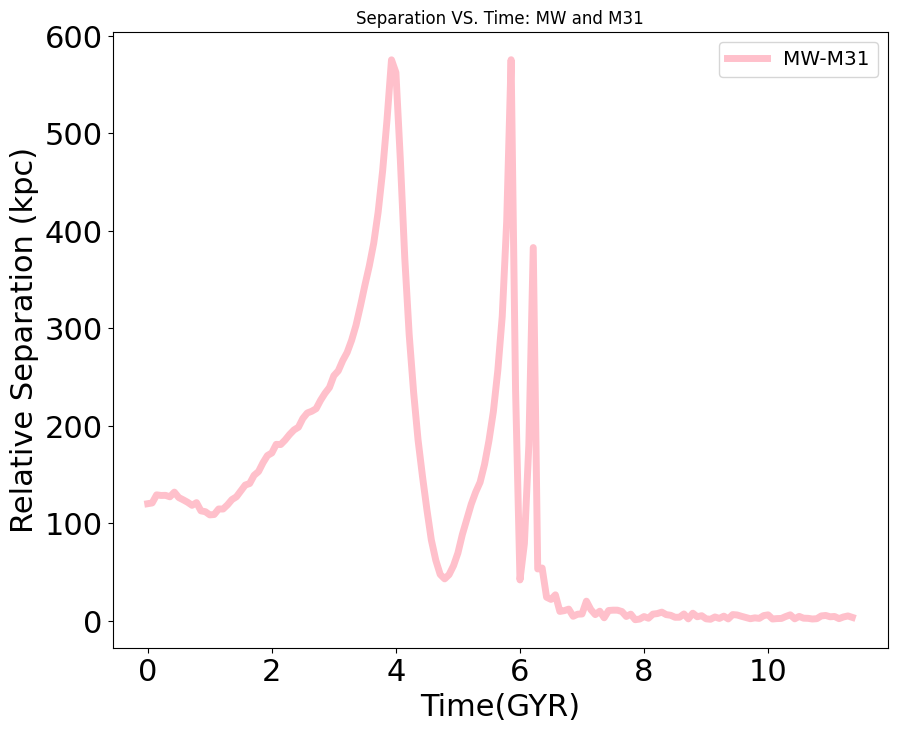

In [18]:
# Plot the orbital velocities of the galaxies 
#################################
fig,ax = plt.subplots(figsize=(10,8))

#adjust tick label font size
label_size = 22
matplotlib.rcParams['xtick.labelsize'] = label_size 
matplotlib.rcParams['ytick.labelsize'] = label_size
#plot magnitude of relative velocity vs time for MW and M31
plt.plot(time1, VelMWM31 ,color = "pink", linewidth = 5, label='MW-M31')

# Axes labels 
plt.xlabel('Time(GYR)',fontsize=22) 
plt.ylabel('Relative Separation (kpc)', fontsize=22)
plt.title("Separation VS. Time: MW and M31")
# Legend
plt.legend(loc='upper right',fontsize='x-large')
plt.show()


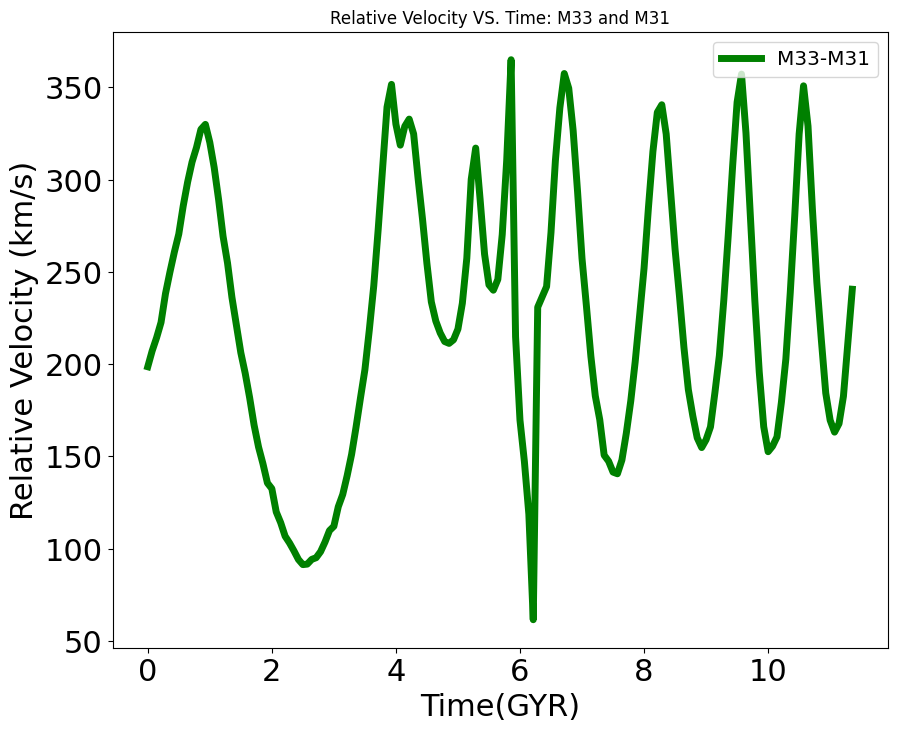

In [19]:
fig,ax = plt.subplots(figsize=(10,8))

#adjust tick label font size
label_size = 22
matplotlib.rcParams['xtick.labelsize'] = label_size 
matplotlib.rcParams['ytick.labelsize'] = label_size
#plot magnitude of relative velocity vs time for M33 and M31
plt.plot(time2, VelM33M31 ,color = "green", linewidth = 5, label='M33-M31')

# Axes labels 
plt.xlabel('Time(GYR)',fontsize=22) 
plt.ylabel('Relative Velocity (km/s)', fontsize=22)
plt.title("Relative Velocity VS. Time: M33 and M31")
# Legeng
plt.legend(loc='upper right',fontsize='x-large')
plt.show()

In [ ]:
########## QUESTIONS##############
#1
# From the sep vs time plot we see The MW and M31 will experience about 2-3 close encounters in the future before coming together.


In [ ]:
#2
# The time evolution of the separation/ relative velocity are related as they seem to do the opposite 
# of what one does. As the separation increases then the velocity decreases and vice versa. 


In [ ]:
#3
# The M31 and MW will merge between about 6.6 to 6.8 Gyr. Its when the separation between the two goes to zero.
# M33's orbit when they decide to merge would cause it's gravity to be effected the most. Leading to various events 
# like getting sucked in and merging also or it could be tossed out into another orbit. 

In [ ]:
#4
# (94-78)/(9.2-10) = 20
# The roughly decay rate of M33's orbit after 6 GYR: about 20 kpc/ GYR I took the points towards the end.
# It will take M33 to merge with the combined MW+M31 remnant at a distance 75 kpc: 75/20 = 3.75 GYR